# Grid Approximation and Quadratic (Laplace) Approximation

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain **why** we need numerical approximations for Bayesian posteriors.
2. Implement **grid approximation** for 1D and 2D problems and understand its limitations.
3. Derive and implement the **quadratic (Laplace) approximation**: find the MAP, compute the Hessian, and approximate the posterior as a Normal.
4. Compare the accuracy of grid, Laplace, and conjugate solutions.
5. Articulate when each approximation method works well and when it breaks down.

## Prerequisites

- [01_bayes_theorem.ipynb](01_bayes_theorem.ipynb) — Bayes' theorem, prior, likelihood, posterior
- [02_conjugate_priors.ipynb](02_conjugate_priors.ipynb) — Beta-Binomial, Gamma-Poisson conjugate families
- [Module 02 — Distributions](../02_distributions/01_discrete_distributions.ipynb) — Binomial, Poisson, Normal, Beta PDFs
- [Module 04 — Estimation](../04_estimation/01_point_estimation.ipynb) — MLE, optimisation basics

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. Why Approximation?

In the previous notebook we saw that **conjugate priors** give us closed-form posteriors: a Beta prior paired with Binomial data yields a Beta posterior, a Gamma prior paired with Poisson data yields a Gamma posterior, and so on. This is elegant, but it only works for a narrow set of model families.

In practice, most interesting models do **not** have conjugate solutions:

- **Logistic regression:** The likelihood is a product of Bernoulli terms with a logit link. No conjugate prior exists for the regression coefficients.
- **Hierarchical models:** Parameters at one level depend on parameters at another. The joint posterior is analytically intractable.
- **Mixture models:** The posterior is multimodal and cannot be expressed in closed form.

When the posterior $p(\theta \mid \mathbf{y})$ has no closed-form expression, we need **numerical methods** to characterise it. This notebook covers the first two:

| Method                                | Idea                                                 | When to use                             |
|---------------------------------------|------------------------------------------------------|-----------------------------------------|
| **Grid approximation**                | Evaluate posterior on a dense grid, normalise        | 1--2 parameters                         |
| **Quadratic (Laplace) approximation** | Approximate posterior as a Normal centred at the MAP | Unimodal, roughly symmetric posteriors  |
| **MCMC** (next notebook)              | Draw correlated samples from the posterior           | General — the workhorse of modern Bayes |

Grid approximation is the most intuitive. Laplace approximation is fast and often surprisingly accurate. MCMC is the most general but the most computationally demanding. Think of this notebook as the **bridge** between the analytical conjugate world and the full power of MCMC.

---

## 2. Grid Approximation

### The Idea

Recall Bayes' theorem:

$$p(\theta \mid \mathbf{y}) = \frac{p(\mathbf{y} \mid \theta) \, p(\theta)}{p(\mathbf{y})}$$

The denominator $p(\mathbf{y}) = \int p(\mathbf{y} \mid \theta) \, p(\theta) \, d\theta$ is just a normalising constant. If we can evaluate the **unnormalised posterior** $p(\mathbf{y} \mid \theta) \, p(\theta)$ at every point in parameter space, we can normalise it ourselves.

Grid approximation turns the continuous integral into a discrete sum:

1. Define a **grid** of parameter values $\theta_1, \theta_2, \dots, \theta_G$.
2. At each grid point, compute the **prior** $p(\theta_g)$.
3. At each grid point, compute the **likelihood** $p(\mathbf{y} \mid \theta_g)$.
4. **Multiply**: $\text{unnormalised}_g = p(\mathbf{y} \mid \theta_g) \cdot p(\theta_g)$.
5. **Normalise**: $p(\theta_g \mid \mathbf{y}) \approx \frac{\text{unnormalised}_g}{\sum_{g=1}^G \text{unnormalised}_g}$.

The result is a discrete approximation to the posterior. As the grid becomes finer ($G \to \infty$), the approximation converges to the true posterior.

### 2.1 One-Dimensional Grid: Beta-Binomial

Let us revisit the Beta-Binomial model from the previous notebook, but now **pretend** we do not know the conjugate solution and use grid approximation instead.

**Setup:** We observe $k = 7$ successes in $n = 10$ trials. Our prior is $\theta \sim \text{Beta}(2, 2)$ (mildly informative, symmetric around 0.5).

The posterior is:

$$p(\theta \mid k, n) \propto \underbrace{\binom{n}{k} \theta^k (1-\theta)^{n-k}}_{\text{likelihood}} \cdot \underbrace{\theta^{\alpha-1}(1-\theta)^{\beta-1} / B(\alpha, \beta)}_{\text{prior}}$$

We know the analytical answer: $\theta \mid k \sim \text{Beta}(\alpha + k, \beta + n - k) = \text{Beta}(9, 5)$. Let us see if grid approximation recovers it.

In [ ]:
# --- Grid approximation: Beta-Binomial (1D) ---

# Data
n_trials, k_success = 10, 7

# Prior: Beta(2, 2)
alpha_prior, beta_prior = 2, 2

# Step 1: Define the grid
G = 1000
theta_grid = np.linspace(0.001, 0.999, G)  # avoid 0 and 1 for numerical safety

# Step 2: Compute prior at each grid point
prior = stats.beta.pdf(theta_grid, alpha_prior, beta_prior)

# Step 3: Compute likelihood at each grid point
likelihood = stats.binom.pmf(k_success, n_trials, theta_grid)

# Step 4: Multiply to get unnormalised posterior
unnorm_posterior = likelihood * prior

# Step 5: Normalise (discrete approximation — sum × grid spacing)
posterior_grid = unnorm_posterior / (
    unnorm_posterior.sum() * (theta_grid[1] - theta_grid[0])
)

# Analytical posterior: Beta(alpha + k, beta + n - k)
alpha_post = alpha_prior + k_success
beta_post = beta_prior + n_trials - k_success
posterior_exact = stats.beta.pdf(theta_grid, alpha_post, beta_post)

print(f"Data: {k_success} successes in {n_trials} trials")
print(f"Prior: Beta({alpha_prior}, {beta_prior})")
print(f"Analytical posterior: Beta({alpha_post}, {beta_post})")
print(
    f"Grid posterior mean ≈ {np.sum(theta_grid * posterior_grid * (theta_grid[1] - theta_grid[0])):.4f}"
)
print(f"Exact posterior mean = {alpha_post / (alpha_post + beta_post):.4f}")

Data: 7 successes in 10 trials
Prior: Beta(2, 2)
Analytical posterior: Beta(9, 5)
Grid posterior mean ≈ 0.6429
Exact posterior mean = 0.6429


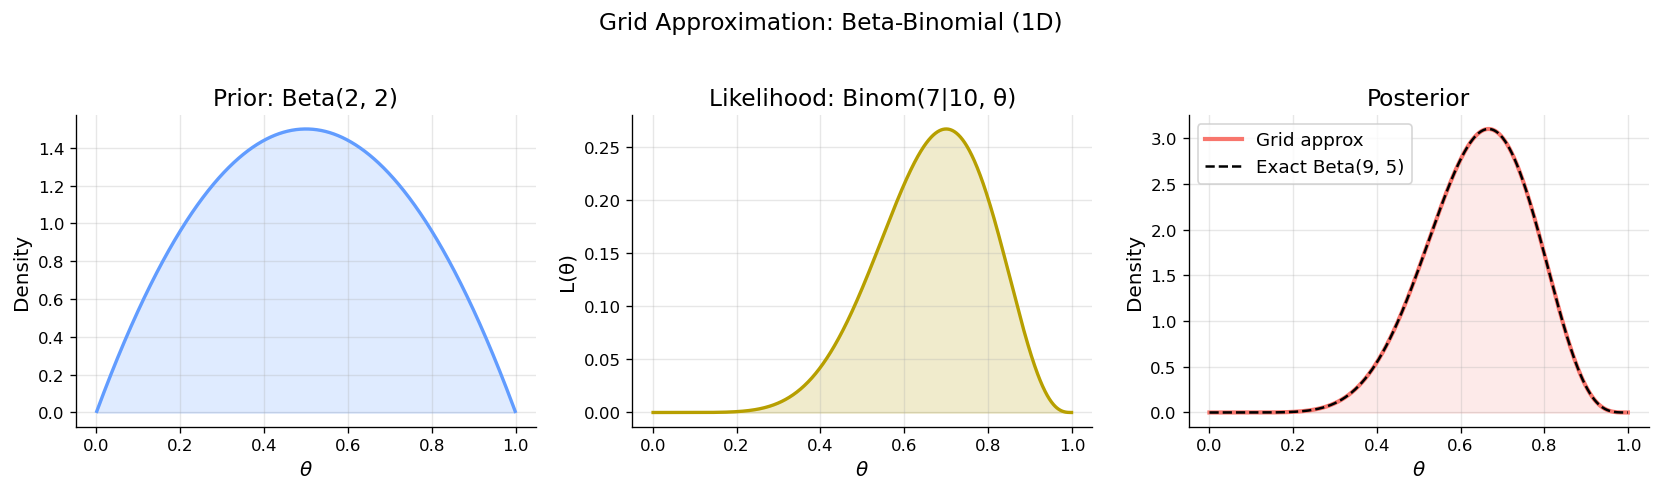

In [ ]:
# Plot: Grid approximation vs. analytical posterior
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Prior
axes[0].plot(theta_grid, prior, color="#619CFF", linewidth=2)
axes[0].fill_between(theta_grid, prior, alpha=0.2, color="#619CFF")
axes[0].set_title(f"Prior: Beta({alpha_prior}, {beta_prior})")
axes[0].set_xlabel(r"$\theta$")
axes[0].set_ylabel("Density")

# Panel 2: Likelihood
axes[1].plot(theta_grid, likelihood, color="#B79F00", linewidth=2)
axes[1].fill_between(theta_grid, likelihood, alpha=0.2, color="#B79F00")
axes[1].set_title(f"Likelihood: Binom({k_success}|{n_trials}, θ)")
axes[1].set_xlabel(r"$\theta$")
axes[1].set_ylabel("L(θ)")

# Panel 3: Grid posterior vs. exact
axes[2].plot(
    theta_grid, posterior_grid, color="#F8766D", linewidth=2.5, label="Grid approx"
)
axes[2].plot(
    theta_grid,
    posterior_exact,
    "--",
    color="black",
    linewidth=1.5,
    label="Exact Beta(9, 5)",
)
axes[2].fill_between(theta_grid, posterior_grid, alpha=0.15, color="#F8766D")
axes[2].set_title("Posterior")
axes[2].set_xlabel(r"$\theta$")
axes[2].set_ylabel("Density")
axes[2].legend()

fig.suptitle("Grid Approximation: Beta-Binomial (1D)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The grid approximation (solid red) lies directly on top of the exact analytical posterior (dashed black). With 1,000 grid points on a single parameter, the approximation is essentially perfect.

### How coarse can the grid be?

Let us compare grids of different sizes to see how the approximation quality degrades.

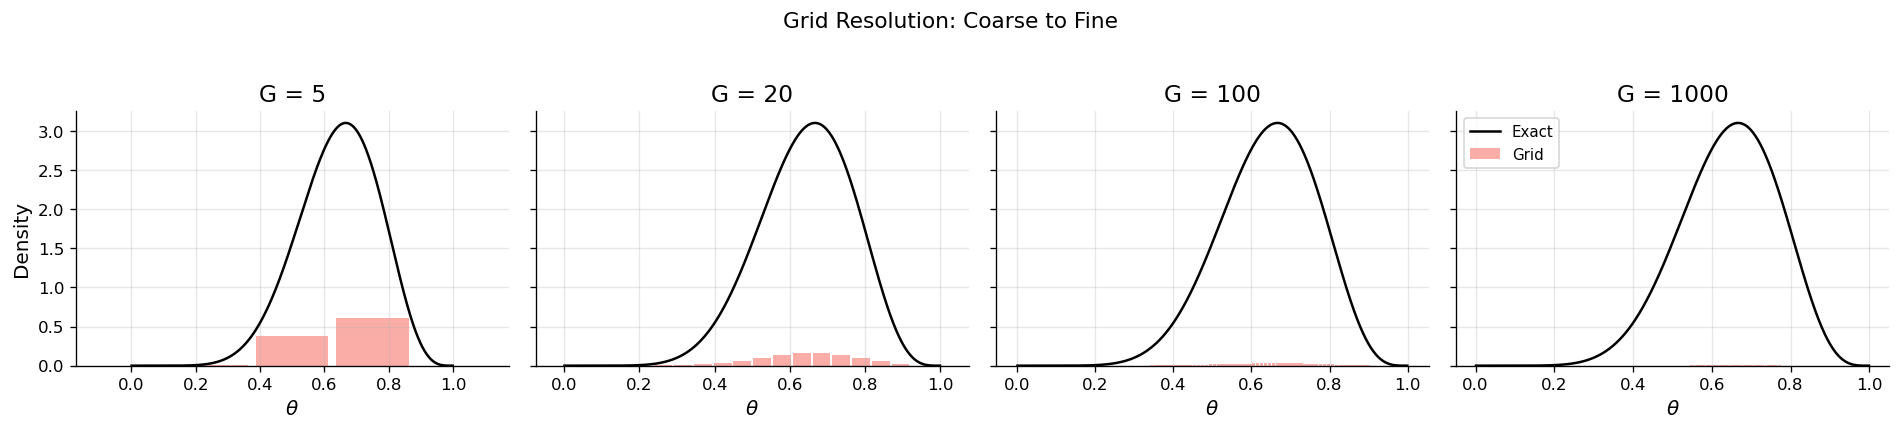

In [ ]:
# Grid approximation quality vs. number of grid points
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, G_val in zip(axes, [5, 20, 100, 1000]):
    grid = np.linspace(0.001, 0.999, G_val)
    pr = stats.beta.pdf(grid, alpha_prior, beta_prior)
    lik = stats.binom.pmf(k_success, n_trials, grid)
    unnorm = lik * pr
    post = unnorm / (unnorm.sum() * (grid[1] - grid[0]))

    ax.bar(
        grid,
        post * (grid[1] - grid[0]),
        width=(grid[1] - grid[0]) * 0.9,
        color="#F8766D",
        alpha=0.6,
        label="Grid",
    )
    fine = np.linspace(0.001, 0.999, 500)
    ax.plot(
        fine,
        stats.beta.pdf(fine, alpha_post, beta_post),
        "k-",
        linewidth=1.5,
        label="Exact",
    )
    ax.set_title(f"G = {G_val}")
    ax.set_xlabel(r"$\theta$")
    if ax == axes[0]:
        ax.set_ylabel("Density")

axes[-1].legend(loc="upper left", fontsize=9)
fig.suptitle("Grid Resolution: Coarse to Fine", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Even 20 grid points give a reasonable approximation for this smooth, unimodal posterior. But for more complex posteriors (multimodal, sharp peaks), you need many more points — and this is where the curse of dimensionality strikes.

### 2.2 Two-Dimensional Grid: Normal Model with Unknown $\mu$ and $\sigma$

Now let us tackle a **two-parameter** problem. Suppose we observe data $y_1, \dots, y_N \sim \text{Normal}(\mu, \sigma^2)$ and want to infer both $\mu$ and $\sigma$.

**Model:**

$$p(\mu, \sigma \mid \mathbf{y}) \propto p(\mathbf{y} \mid \mu, \sigma) \cdot p(\mu) \cdot p(\sigma)$$

We use vague but proper priors:

- $\mu \sim \text{Normal}(0, 10^2)$ — weakly informative
- $\sigma \sim \text{Half-Normal}(0, 5)$ — ensures $\sigma > 0$

The likelihood for $N$ observations:

$$p(\mathbf{y} \mid \mu, \sigma) = \prod_{i=1}^N \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{(y_i - \mu)^2}{2\sigma^2}\right)$$

For a 2D grid, we create a mesh of $(\mu, \sigma)$ values and evaluate the unnormalised posterior at each point.

In [5]:
# Generate some data
true_mu, true_sigma = 3.0, 1.5
y_data = rng.normal(true_mu, true_sigma, size=30)

print(f"True parameters: μ = {true_mu}, σ = {true_sigma}")
print(f"Sample mean = {y_data.mean():.3f}, Sample std = {y_data.std(ddof=1):.3f}")

True parameters: μ = 3.0, σ = 1.5
Sample mean = 3.025, Sample std = 1.165


In [ ]:
# --- 2D Grid Approximation ---

# Grid dimensions
G_mu, G_sigma = 200, 200
mu_grid = np.linspace(1.5, 4.5, G_mu)
sigma_grid = np.linspace(0.5, 3.5, G_sigma)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)

# Log-posterior (working in log space for numerical stability)
log_posterior = np.zeros_like(MU)

for i in range(G_sigma):
    for j in range(G_mu):
        mu_val = MU[i, j]
        sigma_val = SIGMA[i, j]

        # Log-likelihood: Normal
        log_lik = np.sum(stats.norm.logpdf(y_data, loc=mu_val, scale=sigma_val))

        # Log-prior: mu ~ Normal(0, 10), sigma ~ HalfNormal(0, 5)
        log_prior_mu = stats.norm.logpdf(mu_val, loc=0, scale=10)
        log_prior_sigma = stats.halfnorm.logpdf(sigma_val, scale=5)

        log_posterior[i, j] = log_lik + log_prior_mu + log_prior_sigma

# Convert from log to linear, normalise
log_posterior -= log_posterior.max()  # shift for numerical stability
posterior_2d = np.exp(log_posterior)
posterior_2d /= posterior_2d.sum()  # normalise to discrete probabilities

# Find the MAP (maximum a posteriori)
idx_max = np.unravel_index(posterior_2d.argmax(), posterior_2d.shape)
map_mu = mu_grid[idx_max[1]]
map_sigma = sigma_grid[idx_max[0]]
print(f"Grid MAP estimate: μ = {map_mu:.3f}, σ = {map_sigma:.3f}")

Grid MAP estimate: μ = 3.023, σ = 1.148


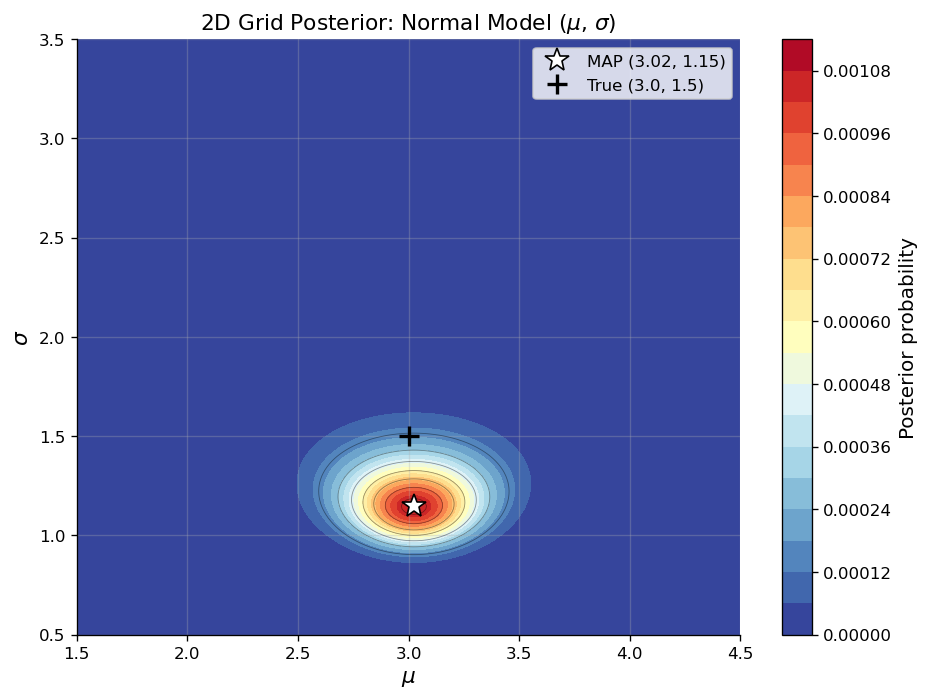

In [ ]:
# Contour plot of the 2D posterior
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(MU, SIGMA, posterior_2d, levels=20, cmap="RdYlBu_r")
ax.contour(MU, SIGMA, posterior_2d, levels=8, colors="k", linewidths=0.5, alpha=0.4)
plt.colorbar(contour, ax=ax, label="Posterior probability")

# Mark the MAP and true values
ax.plot(
    map_mu,
    map_sigma,
    "w*",
    markersize=15,
    markeredgecolor="k",
    label=f"MAP ({map_mu:.2f}, {map_sigma:.2f})",
)
ax.plot(
    true_mu,
    true_sigma,
    "k+",
    markersize=12,
    markeredgewidth=2,
    label=f"True ({true_mu}, {true_sigma})",
)

ax.set_xlabel(r"$\mu$", fontsize=13)
ax.set_ylabel(r"$\sigma$", fontsize=13)
ax.set_title(r"2D Grid Posterior: Normal Model ($\mu$, $\sigma$)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The contour plot shows the joint posterior over $(\mu, \sigma)$. The MAP estimate (white star) is close to the true parameter values (black cross). Notice how the posterior is slightly asymmetric in $\sigma$ — it has a longer right tail, reflecting the fact that standard deviations are bounded below by zero.

We can also extract **marginal posteriors** by summing over the other parameter:

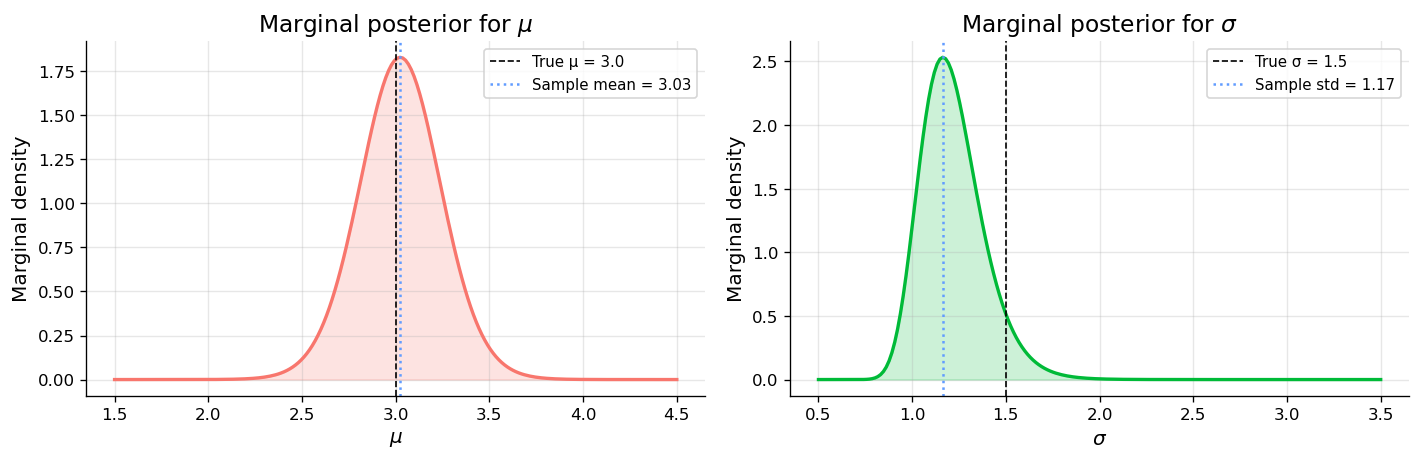

In [ ]:
# Marginal posteriors from the 2D grid
d_mu = mu_grid[1] - mu_grid[0]
d_sigma = sigma_grid[1] - sigma_grid[0]

# Marginal for mu: sum over sigma
marginal_mu = posterior_2d.sum(axis=0)
marginal_mu /= marginal_mu.sum() * d_mu  # normalise to density

# Marginal for sigma: sum over mu
marginal_sigma = posterior_2d.sum(axis=1)
marginal_sigma /= marginal_sigma.sum() * d_sigma  # normalise to density

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(mu_grid, marginal_mu, color="#F8766D", linewidth=2)
ax1.fill_between(mu_grid, marginal_mu, alpha=0.2, color="#F8766D")
ax1.axvline(
    true_mu, color="black", linestyle="--", linewidth=1, label=f"True μ = {true_mu}"
)
ax1.axvline(
    y_data.mean(),
    color="#619CFF",
    linestyle=":",
    linewidth=1.5,
    label=f"Sample mean = {y_data.mean():.2f}",
)
ax1.set_xlabel(r"$\mu$")
ax1.set_ylabel("Marginal density")
ax1.set_title(r"Marginal posterior for $\mu$")
ax1.legend(fontsize=9)

ax2.plot(sigma_grid, marginal_sigma, color="#00BA38", linewidth=2)
ax2.fill_between(sigma_grid, marginal_sigma, alpha=0.2, color="#00BA38")
ax2.axvline(
    true_sigma,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"True σ = {true_sigma}",
)
ax2.axvline(
    y_data.std(ddof=1),
    color="#619CFF",
    linestyle=":",
    linewidth=1.5,
    label=f"Sample std = {y_data.std(ddof=1):.2f}",
)
ax2.set_xlabel(r"$\sigma$")
ax2.set_ylabel("Marginal density")
ax2.set_title(r"Marginal posterior for $\sigma$")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 2.3 The Curse of Dimensionality

Grid approximation scales **exponentially** in the number of parameters. If we use $G$ grid points per parameter:

| Parameters | Grid points           | Time at 1M evals/sec       |
|------------|-----------------------|----------------------------|
| 1          | $G = 1{,}000$         | $< 1$ ms                   |
| 2          | $G^2 = 1{,}000{,}000$ | $\sim 1$ sec               |
| 3          | $G^3 = 10^9$          | $\sim 17$ min              |
| 5          | $G^5 = 10^{15}$       | $\sim 32$ years            |
| 10         | $G^{10} = 10^{30}$    | heat death of the universe |

A typical regression model has tens of parameters. A hierarchical model can have hundreds. Grid approximation is simply **impossible** beyond two or three dimensions.

> **Lesson:** Grid approximation is a wonderful pedagogical tool and fine for 1--2 parameters, but it does not scale. We need smarter methods.

---

## 3. Manim Animation: Grid Approximation Building

The following animation shows grid approximation in action on a 1D parameter. We start with the prior, evaluate the posterior at a coarse set of grid points, then progressively refine the grid. Watch how the discrete dots converge to the smooth posterior curve.

In [9]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C, COLORS

In [ ]:
%%manim -qm -v WARNING GridApprox


class GridApprox(Scene):
    """Animate grid approximation: coarse → fine grid on a 1D posterior."""

    def construct(self):
        from scipy.stats import beta as beta_dist, binom as binom_dist

        # --- Setup: Beta(2,2) prior, 7/10 successes, Beta(9,5) posterior ---
        a_prior, b_prior = 2, 2
        n_obs, k_obs = 10, 7
        a_post, b_post = a_prior + k_obs, b_prior + n_obs - k_obs

        title = Text("Grid Approximation", font_size=30, color=C.LABEL).to_edge(UP)
        self.play(Write(title), run_time=0.6)

        axes = Axes(
            x_range=[0, 1, 0.2],
            y_range=[0, 3.5, 0.5],
            x_length=9,
            y_length=5,
            axis_config={"include_numbers": True, "font_size": 20},
        ).shift(DOWN * 0.3)
        x_lbl = axes.get_x_axis_label(
            MathTex(r"\theta", font_size=24), edge=DOWN, direction=DOWN
        )
        y_lbl = axes.get_y_axis_label(
            Text("Density", font_size=18), edge=LEFT, direction=LEFT
        )
        self.play(Create(axes), Write(x_lbl), Write(y_lbl), run_time=0.7)

        # Draw the prior curve
        def prior_func(t):
            return float(beta_dist.pdf(t, a_prior, b_prior))

        prior_curve = axes.plot(
            prior_func,
            x_range=[0.01, 0.99],
            color=C.PERIWINKLE,
            stroke_width=2.5,
        )
        prior_label = (
            MathTex(r"\text{Prior: Beta}(2,2)", font_size=22, color=C.PERIWINKLE)
            .next_to(axes, UP, buff=0.1)
            .shift(LEFT * 2.5)
        )
        self.play(Create(prior_curve), Write(prior_label), run_time=1)
        self.wait(0.5)

        # Draw likelihood (scaled for visibility)
        # Draw likelihood (scaled for visibility)
        lik_scale = 12.0

        def lik_func(t):
            return float(binom_dist.pmf(k_obs, n_obs, t)) * lik_scale

        lik_curve = axes.plot(
            lik_func,
            x_range=[0.01, 0.99],
            color=C.GOLD,
            stroke_width=2,
            stroke_opacity=0.7,
        )
        lik_label = MathTex(
            r"\text{Likelihood (scaled)}", font_size=22, color=C.GOLD
        ).next_to(prior_label, RIGHT, buff=1)
        self.play(Create(lik_curve), Write(lik_label), run_time=0.8)
        self.wait(0.5)

        # --- Coarse grid: 10 points ---
        def make_grid_dots(n_pts):
            import numpy as _np

            thetas = _np.linspace(0.05, 0.95, n_pts)
            prior_vals = beta_dist.pdf(thetas, a_prior, b_prior)
            lik_vals = binom_dist.pmf(k_obs, n_obs, thetas)
            unnorm = prior_vals * lik_vals
            # normalise to density scale
            spacing = thetas[1] - thetas[0]
            post_vals = unnorm / (unnorm.sum() * spacing)
            dots = VGroup()
            for t, p in zip(thetas, post_vals):
                dot = Dot(axes.c2p(t, p), radius=0.06, color=C.SALMON)
                dots.add(dot)
            return dots, thetas, post_vals

        # Fade out prior and likelihood labels/curves slightly
        self.play(
            prior_curve.animate.set_stroke(opacity=0.3),
            lik_curve.animate.set_stroke(opacity=0.25),
            FadeOut(prior_label),
            FadeOut(lik_label),
            run_time=0.5,
        )

        # Coarse grid: 10 points
        dots_10, _, _ = make_grid_dots(10)
        g_label = Text("G = 10", font_size=22, color=C.SALMON).to_corner(UR)
        self.play(FadeIn(dots_10, lag_ratio=0.1), Write(g_label), run_time=1.5)
        self.wait(0.8)

        # Refine: 25 points
        dots_25, _, _ = make_grid_dots(25)
        g_label_25 = Text("G = 25", font_size=22, color=C.SALMON).to_corner(UR)
        self.play(
            Transform(dots_10, dots_25),
            Transform(g_label, g_label_25),
            run_time=1,
        )
        self.wait(0.6)

        # Refine: 80 points
        dots_80, _, _ = make_grid_dots(80)
        g_label_80 = Text("G = 80", font_size=22, color=C.SALMON).to_corner(UR)
        self.play(
            Transform(dots_10, dots_80),
            Transform(g_label, g_label_80),
            run_time=1,
        )
        self.wait(0.6)

        # Draw exact posterior for comparison
        def post_func(t):
            return float(beta_dist.pdf(t, a_post, b_post))

        exact_curve = axes.plot(
            post_func,
            x_range=[0.01, 0.99],
            color=C.SALMON,
            stroke_width=3,
        )
        exact_label = (
            MathTex(r"\text{Exact: Beta}(9,5)", font_size=22, color=C.SALMON)
            .next_to(axes, UP, buff=0.1)
            .shift(RIGHT * 2)
        )
        self.play(
            Create(exact_curve),
            Write(exact_label),
            FadeOut(dots_10),
            FadeOut(g_label),
            run_time=1.2,
        )
        self.wait(1.5)

The animation shows the core insight: grid approximation evaluates the posterior at discrete points and, as the grid refines, the discrete dots converge to the smooth posterior curve. Even a coarse grid of 10 points captures the rough shape; 80 points are nearly indistinguishable from the exact solution.

---

## 4. Quadratic (Laplace) Approximation

### The Idea

The Laplace approximation takes a fundamentally different approach. Instead of evaluating the posterior everywhere, it:

1. Finds the **mode** of the posterior (the MAP estimate).
2. Approximates the posterior by a **Normal distribution** centred at the mode, with covariance determined by the **curvature** at the mode.

The justification is a **second-order Taylor expansion** of the log-posterior around the MAP.

### Derivation

Let $\hat{\theta} = \arg\max_{\theta} \log p(\theta \mid \mathbf{y})$ be the MAP estimate. Taylor-expand the log-posterior around $\hat{\theta}$:

$$\log p(\theta \mid \mathbf{y}) \approx \log p(\hat{\theta} \mid \mathbf{y}) + \underbrace{\nabla \log p(\hat{\theta} \mid \mathbf{y})}_{= \, 0 \text{ at mode}} (\theta - \hat{\theta}) + \frac{1}{2} (\theta - \hat{\theta})^T \mathbf{H} (\theta - \hat{\theta})$$

where $\mathbf{H} = \nabla^2 \log p(\hat{\theta} \mid \mathbf{y})$ is the **Hessian** of the log-posterior evaluated at the MAP. The first-order term vanishes because $\hat{\theta}$ is a maximum.

Exponentiating both sides:

$$p(\theta \mid \mathbf{y}) \approx p(\hat{\theta} \mid \mathbf{y}) \cdot \exp\left(\frac{1}{2} (\theta - \hat{\theta})^T \mathbf{H} (\theta - \hat{\theta})\right)$$

This is the kernel of a **multivariate Normal** with:

$$\boxed{p(\theta \mid \mathbf{y}) \approx \text{Normal}\left(\hat{\theta}, \, \Sigma = -\mathbf{H}^{-1}\right)}$$

The covariance matrix is the negative inverse Hessian. A sharply peaked posterior (large negative curvature) gives a small covariance (high precision), and vice versa.

### Connection to MLE

Note that the MAP estimate is just the MLE with a prior:

$$\hat{\theta}_{\text{MAP}} = \arg\max_{\theta} \left[ \log p(\mathbf{y} \mid \theta) + \log p(\theta) \right]$$

With a flat (uniform) prior, the MAP equals the MLE. With a proper prior, the MAP is a **penalised MLE** — the prior acts as a regulariser. This connects Bayesian inference directly to the penalised likelihood methods from frequentist statistics (e.g., ridge regression = Normal prior on coefficients).

### 4.1 Implementing Laplace Approximation: Gamma-Poisson Example

**Setup:** We observe counts $y_1, \dots, y_N \sim \text{Poisson}(\lambda)$ and place a $\text{Gamma}(3, 1)$ prior on $\lambda$.

This is a conjugate pair (the posterior is $\text{Gamma}(3 + \sum y_i, 1 + N)$), so we can compare the Laplace approximation to the exact answer.

**Steps:**

1. Define the **negative log-posterior** (we minimise this to find the MAP).
2. Use `scipy.optimize.minimize` to find $\hat{\lambda}_{\text{MAP}}$.
3. Extract the **Hessian** at the MAP (from the inverse of the optimiser's Hessian approximation, or by finite differences).
4. Construct the Normal approximation: $\text{Normal}(\hat{\lambda}, (-H)^{-1})$.

In [13]:
# --- Laplace Approximation: Gamma-Poisson ---

# Generate Poisson data
true_lambda = 4.5
N_obs = 25
y_pois = rng.poisson(true_lambda, size=N_obs)

print(f"True λ = {true_lambda}")
print(f"Observed: n = {N_obs}, sum(y) = {y_pois.sum()}, mean(y) = {y_pois.mean():.2f}")

# Prior: Gamma(shape=3, rate=1) → in scipy parameterisation: Gamma(a=3, scale=1)
gamma_shape, gamma_rate = 3, 1

# Exact conjugate posterior: Gamma(shape + sum_y, rate + N)
post_shape = gamma_shape + y_pois.sum()
post_rate = gamma_rate + N_obs
print(f"\nExact posterior: Gamma(shape={post_shape}, rate={post_rate})")
print(f"Exact posterior mean = {post_shape / post_rate:.4f}")
print(f"Exact posterior mode = {(post_shape - 1) / post_rate:.4f}")

True λ = 4.5
Observed: n = 25, sum(y) = 103, mean(y) = 4.12

Exact posterior: Gamma(shape=106, rate=26)
Exact posterior mean = 4.0769
Exact posterior mode = 4.0385


In [ ]:
# Step 1: Define the negative log-posterior
def neg_log_posterior(lam, y, a, b):
    """Negative log-posterior for Poisson(λ) with Gamma(a, b) prior.

    Parameters
    ----------
    lam : float — the Poisson rate parameter (must be > 0)
    y : array — observed counts
    a : float — Gamma shape parameter
    b : float — Gamma rate parameter
    """
    if lam <= 0:
        return 1e12  # penalty for invalid parameter
    # Log-likelihood: sum of Poisson log-PMF
    log_lik = np.sum(stats.poisson.logpmf(y, mu=lam))
    # Log-prior: Gamma(a, scale=1/b)
    log_prior = stats.gamma.logpdf(lam, a=a, scale=1.0 / b)
    return -(log_lik + log_prior)


# Step 2: Find the MAP using scipy.optimize.minimize
result = minimize(
    neg_log_posterior,
    x0=[3.0],  # starting guess
    args=(y_pois, gamma_shape, gamma_rate),
    method="L-BFGS-B",
    bounds=[(1e-6, None)],  # λ > 0
)

lam_map = result.x[0]
print(f"MAP estimate (optimiser): λ̂ = {lam_map:.4f}")
print(f"Exact MAP (mode):         λ̂ = {(post_shape - 1) / post_rate:.4f}")

MAP estimate (optimiser): λ̂ = 4.0385
Exact MAP (mode):         λ̂ = 4.0385


In [ ]:
# Step 3: Compute the Hessian at the MAP via finite differences
from scipy.optimize import approx_fprime


def hessian_1d(f, x0, args=(), eps=1e-5):
    """Compute the 1D second derivative (Hessian) by central finite differences."""
    f_plus = f(x0 + eps, *args)
    f_center = f(x0, *args)
    f_minus = f(x0 - eps, *args)
    return (f_plus - 2 * f_center + f_minus) / eps**2


# Hessian of the NEGATIVE log-posterior at MAP
H = hessian_1d(neg_log_posterior, lam_map, args=(y_pois, gamma_shape, gamma_rate))

# Variance of Laplace approximation = 1/H (since H is of the negative log-posterior)
laplace_var = 1.0 / H
laplace_sd = np.sqrt(laplace_var)

print(f"Hessian of neg-log-posterior at MAP: H = {H:.4f}")
print(f"Laplace approximation: Normal(μ={lam_map:.4f}, σ={laplace_sd:.4f})")
print(f"\nExact posterior std = {np.sqrt(post_shape / post_rate**2):.4f}")

Hessian of neg-log-posterior at MAP: H = 6.4377
Laplace approximation: Normal(μ=4.0385, σ=0.3941)

Exact posterior std = 0.3960


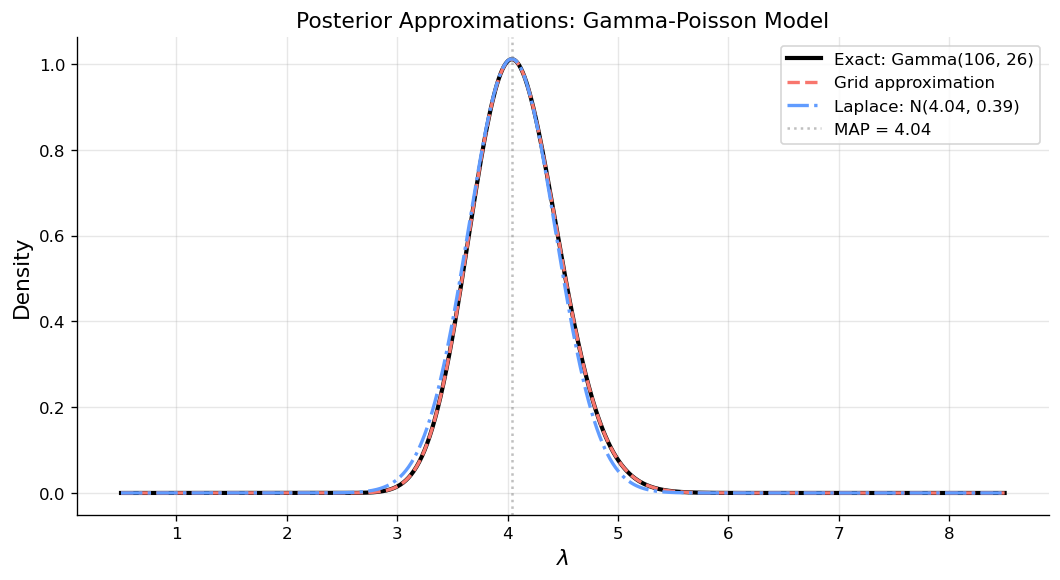

In [ ]:
# Step 4: Compare Laplace approximation, grid approximation, and exact posterior

# Grid approximation for comparison
lam_grid = np.linspace(0.5, 8.5, 1000)
grid_prior = stats.gamma.pdf(lam_grid, a=gamma_shape, scale=1.0 / gamma_rate)
grid_lik = np.array([np.prod(stats.poisson.pmf(y_pois, mu=l)) for l in lam_grid])
grid_unnorm = grid_prior * grid_lik
grid_post = grid_unnorm / (grid_unnorm.sum() * (lam_grid[1] - lam_grid[0]))

# Exact posterior: Gamma(post_shape, rate=post_rate)
exact_post = stats.gamma.pdf(lam_grid, a=post_shape, scale=1.0 / post_rate)

# Laplace approximation: Normal(lam_map, laplace_sd)
laplace_post = stats.norm.pdf(lam_grid, loc=lam_map, scale=laplace_sd)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    lam_grid,
    exact_post,
    "k-",
    linewidth=2.5,
    label=f"Exact: Gamma({post_shape}, {post_rate})",
)
ax.plot(
    lam_grid, grid_post, "--", color="#F8766D", linewidth=2, label="Grid approximation"
)
ax.plot(
    lam_grid,
    laplace_post,
    "-.",
    color="#619CFF",
    linewidth=2,
    label=f"Laplace: N({lam_map:.2f}, {laplace_sd:.2f})",
)
ax.axvline(
    lam_map, color="grey", linestyle=":", alpha=0.5, label=f"MAP = {lam_map:.2f}"
)

ax.set_xlabel(r"$\lambda$", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title("Posterior Approximations: Gamma-Poisson Model", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

All three methods agree well. The grid approximation (dashed red) overlaps the exact Gamma posterior (solid black) almost perfectly. The Laplace approximation (dash-dot blue) captures the location and spread accurately, though it is symmetric by construction — it cannot represent the slight right-skew of the Gamma posterior.

With 25 observations, the posterior is dominated by the likelihood, and the likelihood is approximately Normal by the central limit theorem. This is why Laplace works so well here.

### 4.2 When Laplace Fails: Skewed and Multimodal Posteriors

The Laplace approximation assumes the posterior is well described by a single Normal. This can go badly wrong when the posterior is:

1. **Heavily skewed** — e.g., when the parameter is near a boundary.
2. **Multimodal** — e.g., in mixture models.

Let us see an example of each.

Small sample data: [2 1 0], sum = 3


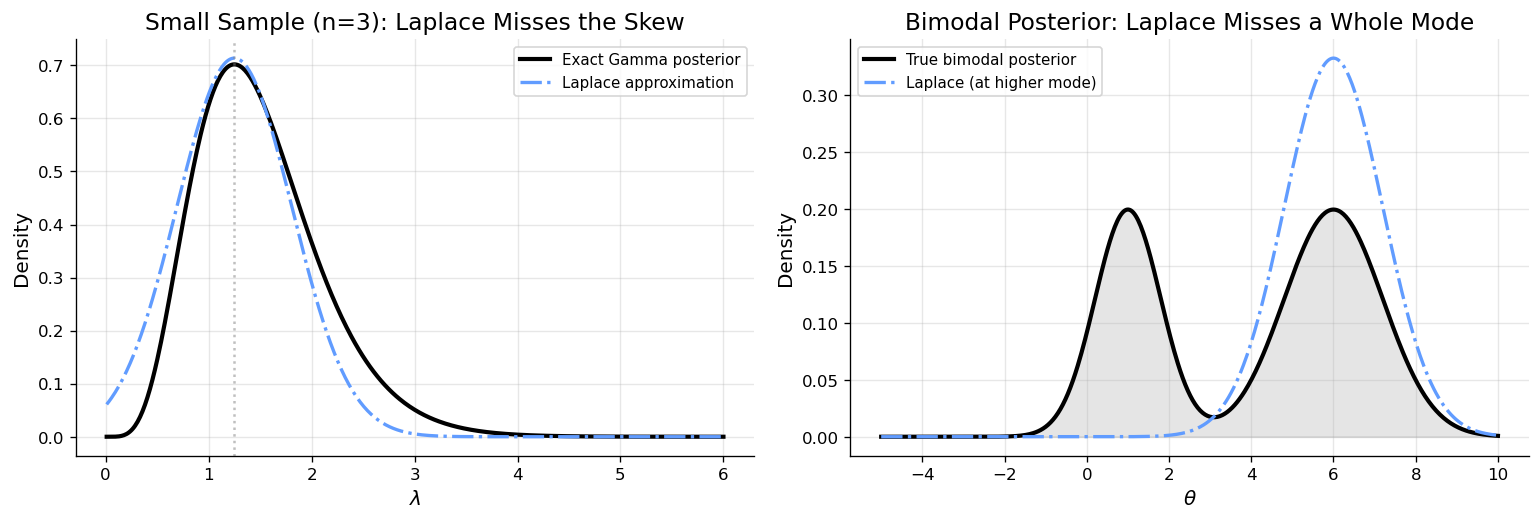

In [ ]:
# --- Case 1: Skewed posterior (small sample) ---
# With very few observations and a prior near the boundary, the posterior is skewed.

y_small = rng.poisson(1.5, size=3)  # very few observations
print(f"Small sample data: {y_small}, sum = {y_small.sum()}")

# Exact posterior: Gamma(3 + sum_y, 1 + 3)
post_a_small = gamma_shape + y_small.sum()
post_b_small = gamma_rate + len(y_small)

# Laplace approximation
res_small = minimize(
    neg_log_posterior,
    x0=[2.0],
    args=(y_small, gamma_shape, gamma_rate),
    method="L-BFGS-B",
    bounds=[(1e-6, None)],
)
map_small = res_small.x[0]
H_small = hessian_1d(
    neg_log_posterior, map_small, args=(y_small, gamma_shape, gamma_rate)
)
sd_small = np.sqrt(1.0 / H_small)

lam_fine = np.linspace(0.01, 6, 500)
exact_small = stats.gamma.pdf(lam_fine, a=post_a_small, scale=1.0 / post_b_small)
laplace_small = stats.norm.pdf(lam_fine, loc=map_small, scale=sd_small)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(lam_fine, exact_small, "k-", linewidth=2.5, label="Exact Gamma posterior")
ax1.plot(
    lam_fine,
    laplace_small,
    "-.",
    color="#619CFF",
    linewidth=2,
    label="Laplace approximation",
)
ax1.axvline(map_small, color="grey", linestyle=":", alpha=0.5)
ax1.set_xlabel(r"$\lambda$")
ax1.set_ylabel("Density")
ax1.set_title(f"Small Sample (n={len(y_small)}): Laplace Misses the Skew")
ax1.legend(fontsize=9)

# --- Case 2: Bimodal "posterior" (synthetic) ---
# Mixture of two Normals to illustrate multimodality
x_bimodal = np.linspace(-5, 10, 500)
bimodal_pdf = 0.4 * stats.norm.pdf(x_bimodal, loc=1, scale=0.8) + 0.6 * stats.norm.pdf(
    x_bimodal, loc=6, scale=1.2
)

# Laplace at the higher mode
mode_2 = 6.0
# approximate variance from the second component
laplace_bimodal = stats.norm.pdf(x_bimodal, loc=mode_2, scale=1.2)

ax2.plot(x_bimodal, bimodal_pdf, "k-", linewidth=2.5, label="True bimodal posterior")
ax2.plot(
    x_bimodal,
    laplace_bimodal,
    "-.",
    color="#619CFF",
    linewidth=2,
    label="Laplace (at higher mode)",
)
ax2.fill_between(x_bimodal, bimodal_pdf, alpha=0.1, color="black")
ax2.set_xlabel(r"$\theta$")
ax2.set_ylabel("Density")
ax2.set_title("Bimodal Posterior: Laplace Misses a Whole Mode")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Left panel:** With only 3 observations, the Gamma posterior is noticeably right-skewed. The Laplace approximation (symmetric by construction) underestimates probability in the right tail and overestimates it in the left tail. For decisions sensitive to tail behaviour (e.g., credible intervals), this matters.

**Right panel:** A bimodal posterior has two peaks, but Laplace can only capture one. It centres a Normal on the dominant mode and completely ignores the other. Any summary based on the Laplace approximation would miss an entire region of high posterior probability.

> **Rule of thumb:** Laplace approximation works well when (a) the posterior is unimodal, (b) the posterior is approximately symmetric (which happens with enough data, by the Bernstein-von Mises theorem), and (c) you need a quick answer. When in doubt, use MCMC.

### 4.3 Multivariate Laplace Approximation

The Laplace approximation generalises naturally to multiple parameters. For a $d$-dimensional parameter vector $\boldsymbol{\theta}$:

1. **Find the MAP:** $\hat{\boldsymbol{\theta}} = \arg\max_{\boldsymbol{\theta}} \log p(\boldsymbol{\theta} \mid \mathbf{y})$.
2. **Compute the Hessian matrix:** $\mathbf{H} = \nabla^2 \log p(\boldsymbol{\theta} \mid \mathbf{y}) \big|_{\boldsymbol{\theta} = \hat{\boldsymbol{\theta}}}$ (a $d \times d$ matrix).
3. **Approximate:** $p(\boldsymbol{\theta} \mid \mathbf{y}) \approx \text{Normal}_d\left(\hat{\boldsymbol{\theta}}, \, -\mathbf{H}^{-1}\right)$.

The covariance matrix $\Sigma = -\mathbf{H}^{-1}$ captures not only the marginal uncertainties (diagonal entries) but also the **correlations** between parameters (off-diagonal entries).

Let us apply this to the Normal model from Section 2.2.

In [ ]:
# --- Multivariate Laplace: Normal model with unknown mu and sigma ---


def neg_log_post_normal(params, y):
    """Negative log-posterior for Normal(mu, sigma) with weakly informative priors.

    params: [mu, log_sigma]  (we optimise in log-sigma for unconstrained optimisation)
    Priors: mu ~ Normal(0, 10), sigma ~ HalfNormal(0, 5)
    """
    mu, log_sigma = params
    sigma = np.exp(log_sigma)  # ensure sigma > 0

    # Log-likelihood
    log_lik = np.sum(stats.norm.logpdf(y, loc=mu, scale=sigma))
    # Log-priors
    log_prior_mu = stats.norm.logpdf(mu, loc=0, scale=10)
    log_prior_sigma = stats.halfnorm.logpdf(sigma, scale=5)
    # Jacobian adjustment for log-sigma transformation
    log_jacobian = log_sigma  # d(sigma)/d(log_sigma) = sigma = exp(log_sigma)

    return -(log_lik + log_prior_mu + log_prior_sigma + log_jacobian)


# Find MAP
res_2d = minimize(
    neg_log_post_normal,
    x0=[0.0, 0.0],  # [mu_init, log_sigma_init]
    args=(y_data,),
    method="L-BFGS-B",
)

mu_map = res_2d.x[0]
sigma_map = np.exp(res_2d.x[1])
print(f"MAP: μ = {mu_map:.4f}, σ = {sigma_map:.4f}")
print(f"Sample statistics: mean = {y_data.mean():.4f}, std = {y_data.std(ddof=1):.4f}")

MAP: μ = 3.0239, σ = 1.1640
Sample statistics: mean = 3.0252, std = 1.1651


In [ ]:
# Compute Hessian numerically at the MAP
from scipy.optimize import approx_fprime


def hessian_nd(f, x0, args=(), eps=1e-5):
    """Compute the Hessian matrix by central finite differences."""
    n = len(x0)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n)
            ei[i] = eps
            ej = np.zeros(n)
            ej[j] = eps
            H[i, j] = (
                f(x0 + ei + ej, *args)
                - f(x0 + ei - ej, *args)
                - f(x0 - ei + ej, *args)
                + f(x0 - ei - ej, *args)
            ) / (4 * eps**2)
    return H


H_2d = hessian_nd(neg_log_post_normal, res_2d.x, args=(y_data,))
cov_laplace = np.linalg.inv(H_2d)  # Σ = H⁻¹ (H is of the *negative* log-posterior)

print("Hessian of neg-log-posterior at MAP:")
print(H_2d.round(4))
print("\nLaplace covariance matrix (in [μ, log σ] space):")
print(cov_laplace.round(6))
print(
    f"\nMarginal SDs: σ_μ = {np.sqrt(cov_laplace[0, 0]):.4f}, σ_log_σ = {np.sqrt(cov_laplace[1, 1]):.4f}"
)

Hessian of neg-log-posterior at MAP:
[[22.1505  0.0605]
 [ 0.0605 58.2168]]

Laplace covariance matrix (in [μ, log σ] space):
[[ 4.5146e-02 -4.7000e-05]
 [-4.7000e-05  1.7177e-02]]

Marginal SDs: σ_μ = 0.2125, σ_log_σ = 0.1311


The Laplace approximation gives us a bivariate Normal in the $(\mu, \log\sigma)$ space. The off-diagonal elements of the covariance matrix tell us about the correlation between $\mu$ and $\log\sigma$ — which is typically small for the Normal model.

---

## 5. Comparison of Methods

Let us now step back and compare all the approximation methods we have seen so far.

| Method        | When to use                           | Accuracy                                   | Speed                                      | Limitations                                        |
|---------------|---------------------------------------|--------------------------------------------|--------------------------------------------|----------------------------------------------------|
| **Conjugate** | Prior-likelihood pair is conjugate    | Exact                                      | Instant                                    | Restricted to conjugate families                   |
| **Grid**      | 1--2 parameters                       | Excellent (with fine grid)                 | Fast for 1D, feasible for 2D               | Curse of dimensionality: $G^d$ grows exponentially |
| **Laplace**   | Unimodal, roughly symmetric posterior | Good when assumptions hold                 | Very fast ($O(d^3)$ for Hessian inversion) | Misses skewness, multimodality                     |
| **MCMC**      | General — the workhorse               | Arbitrarily accurate (with enough samples) | Slower, requires convergence checks        | Computational cost, mixing issues                  |

### When to use what

- **Start with conjugate solutions** when they exist. They are exact, fast, and require no tuning.
- **Use grid approximation for teaching and low-dimensional exploration.** It builds intuition about how priors and likelihoods combine.
- **Use Laplace approximation for quick posterior summaries** in models with many parameters and well-behaved posteriors. This is what R's `quap()` (from *Statistical Rethinking*) does under the hood.
- **Use MCMC when the posterior is complex**: skewed, multimodal, high-dimensional, or when you need full posterior samples for derived quantities. This is the subject of the [next notebook](04_mcmc_from_scratch.ipynb).

---

## Exercises

**Exercise 3.1 (Grid — effect of sample size).** Using the Beta-Binomial model with a $\text{Beta}(1, 1)$ (uniform) prior, implement grid approximation for the following datasets:
- (a) $k = 3, n = 5$
- (b) $k = 30, n = 50$
- (c) $k = 300, n = 500$

Plot the prior, likelihood, and posterior for each case. How does increasing $n$ (with $k/n$ held constant at 0.6) change the posterior? Compare with the exact Beta posterior in each case.

**Exercise 3.2 (Grid — 2D credible region).** Using the 2D grid posterior for the Normal model (Section 2.2), compute the 90% **highest posterior density (HPD) region** for $(\mu, \sigma)$. *Hint:* sort the grid posterior values in decreasing order, accumulate probability mass, and find the threshold that encloses 90%. Plot the HPD region as a shaded contour.

**Exercise 3.3 (Laplace — Beta-Binomial).** Apply the Laplace approximation to the Beta-Binomial model from Section 2.1 ($k = 7, n = 10$, $\text{Beta}(2, 2)$ prior). Work on the logit scale: let $\phi = \log(\theta / (1-\theta))$, find the MAP in $\phi$-space, compute the Hessian, and transform back to $\theta$-space. Compare with the exact Beta(9, 5) posterior. *Why* is the logit transformation useful here?

**Exercise 3.4 (Laplace — multiple parameters).** Consider a simple linear regression $y_i = \beta_0 + \beta_1 x_i + \epsilon_i$ with $\epsilon_i \sim \text{Normal}(0, \sigma^2)$. Place weakly informative priors: $\beta_0, \beta_1 \sim \text{Normal}(0, 10)$, $\sigma \sim \text{HalfNormal}(0, 5)$. Generate data from $\beta_0 = 1, \beta_1 = 2, \sigma = 1$ with 50 observations. Implement the Laplace approximation to get the joint posterior Normal$(\hat{\boldsymbol{\theta}}, -\mathbf{H}^{-1})$ for $\boldsymbol{\theta} = (\beta_0, \beta_1, \log\sigma)$. Report the MAP estimates and 95% credible intervals.

**Exercise 3.5 (Comparison).** For the Beta-Binomial model with $k = 2, n = 5$ and a $\text{Beta}(0.5, 0.5)$ (Jeffreys) prior:
- (a) Compute the exact posterior.
- (b) Implement grid approximation with $G = 500$.
- (c) Implement the Laplace approximation.
- (d) Plot all three on the same figure. Which approximation performs worse, and why? *Hint:* look at the shape of the Jeffreys prior near the boundaries.

---

## Key Takeaways

1. **Most posteriors have no closed form.** Conjugate solutions are the exception, not the rule. Numerical approximation is essential.
2. **Grid approximation** evaluates the posterior on a dense grid and normalises. It is exact in the limit but scales as $G^d$ — impractical beyond 2 parameters.
3. **The Laplace (quadratic) approximation** fits a Normal distribution at the posterior mode. It requires only an optimisation and a Hessian computation — fast and scalable, but assumes the posterior is unimodal and roughly symmetric.
4. **The MAP estimate** is a penalised MLE — the prior acts as a regulariser. With a flat prior, MAP = MLE.
5. **Neither grid nor Laplace is general enough** for the complex posteriors that arise in hierarchical models, mixture models, or high-dimensional problems. For those, we need **MCMC** — the subject of the next notebook.

**Next:** [04_mcmc_from_scratch.ipynb](04_mcmc_from_scratch.ipynb) — Markov Chain Monte Carlo: the Metropolis-Hastings algorithm, implemented from scratch.

In [ ]:
cfg.save_gifs(clean=True)